In [1]:
# import os

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import jax
import jax.numpy as jnp

jax.config.update("jax_compilation_cache_dir", "./jax-caches")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

from desc import set_device
set_device("gpu")

In [3]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go

In [4]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *
from desc.particles import *
from diffrax import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic
from desc.compute.data_index import register_compute_fun
from desc.optimize.utils import solve_triangular_regularized

print_backend_info()

DESC version=0.17.1+8.gd628bcadb.
Using JAX backend: jax version=0.7.2, jaxlib version=0.7.2, dtype=float64.
Using device: NVIDIA A100-PCIE-40GB (id=0), with 40.00 GB available memory.


In [5]:
from extra_objectives import CoilBounds, SurfaceMatch

In [6]:
# extra plotting functions
from plotting_yge import plot_grid_3d, plot_coil_and_surfaces

# About this Notebook

We will optimize an umbilic coil for HBT hybrid design.

In [7]:
# eq0 = load("eq_final2.h5")
eq0 = load("./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb.h5")
field0 = load("./coils/coils-eq-HBT_105995_06-rev-curr-stage2-fb.h5")
all_HBT_coils_wo_tf = field0[1:]
all_HBT_coils_wo_tf = MixedCoilSet(all_HBT_coils_wo_tf)
tf = ToroidalMagneticField(B0=0.32, R0=0.92)
field0 = [tf, all_HBT_coils_wo_tf]
use_coil2 = False

## First get N!=0 and NFP=1 Solution

In [8]:
field = field0.copy()

In [9]:
eq = eq0.copy()
eq.change_resolution(L=16, M=16, L_grid=24, M_grid=24, N=3, N_grid=6, NFP=1, sym=True)
# eq.change_resolution(N=2, N_grid=4, NFP=1, sym=True)
coil_grid = LinearGrid(N=50)
eval_grid = LinearGrid(
    rho=np.array([1.0]), M=32, N=64, NFP=1, sym=False
)
source_grid = LinearGrid(
    rho=np.array([1.0]), M=32, N=64, NFP=1, sym=False
)
eq

/home/ye2698/DESC/desc/utils.py:563: UserWarning: Reducing radial (L) resolution can make plasma boundary inconsistent. Recommend calling `eq.surface = eq.get_surface_at(rho=1.0)`
  warnings.warn(msg, err)


Equilibrium at 0x14a0b2f72710 (L=16, M=16, N=3, NFP=1, sym=True, spectral_indexing=ansi)

In [10]:
name = f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}.h5"
try:
    eq = load(name)
except FileNotFoundError:
    eq.solve(maxiter=300, ftol=1e-4, gtol=0, xtol=0, verbose=3);

In [11]:
eq.save(name)

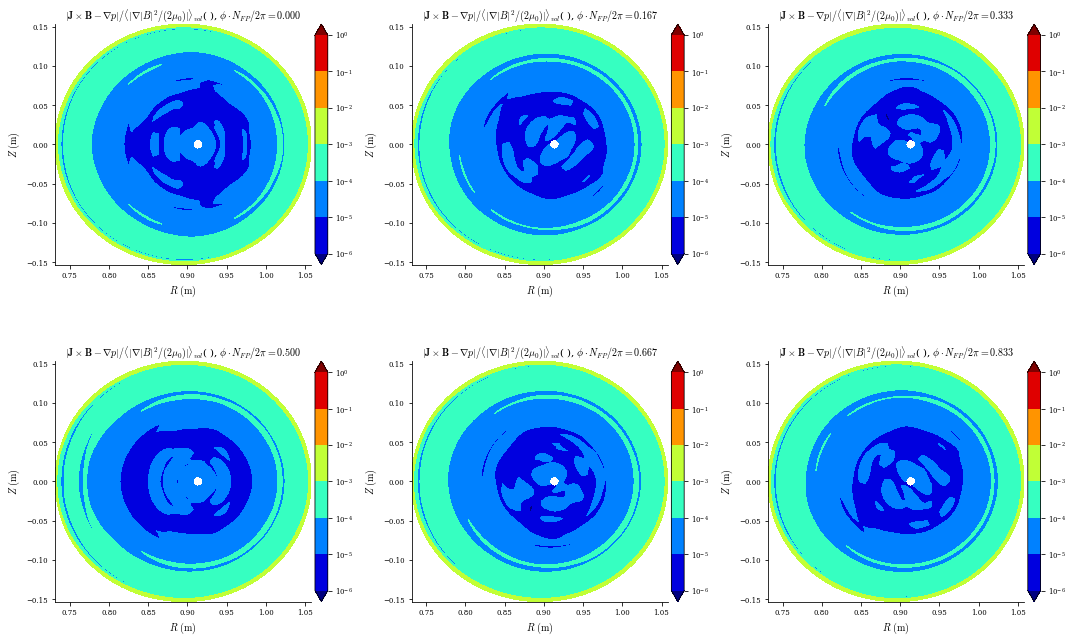

In [12]:
plot_section(eq, "|F|_normalized", log=True);

In [13]:
# eq.current *= -1
# eq.Psi *= -1
# eq.iota = eq.get_profile("iota")

objective = ObjectiveFunction(
    BoundaryError(
        eq=eq,
        field=field,
        field_fixed=True,
        field_grid=coil_grid,
        source_grid=source_grid,
        eval_grid=eval_grid,
        b_plasma_chunk_size=200,
        bs_chunk_size=200,
    ),
    jac_chunk_size=1,
)
constraints = (
    ForceBalance(eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid)),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

In [14]:
eq0_lowres = eq.copy()

In [15]:
try:
    eq = load(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-fb-k4.h5")
except FileNotFoundError:
    k = 4
    R_modes = np.vstack(
        (
            # [0, 0, 0],  # kind of cheating...
            eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :],
        )
    )
    Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
    bdry_constraints = (
        FixBoundaryR(eq=eq, modes=R_modes),
        FixBoundaryZ(eq=eq, modes=Z_modes),
    )
    eq, out = eq.optimize(
        objective,
        constraints + bdry_constraints,
        optimizer="proximal-lsq-exact",
        x_scale="ess",
        verbose=3,
        maxiter=30,
        ftol=1e-3,
        options={"solve_options":{"ftol": 1e-3, "gtol": 0, "xtol": 0, "verbose": 0}},
    )

Building objective: Boundary error
Precomputing transforms
Timer: Precomputing transforms = 114 ms
Timer: Objective build = 1.55 sec
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 194 ms
Timer: Objective build = 234 ms
Timer: Objective build = 3.21 ms
Timer: Eq Update LinearConstraintProjection build = 2.33 sec
Timer: Proximal projection build = 14.5 sec
Building objective: fixed pressure
Building objective: fixed Psi
Building objective: fixed current
Building objective: lcfs R
Building objective: lcfs Z
Timer: Objective build = 588 ms
Timer: LinearConstraintProjection build = 906 ms
Number of parameters: 63
Number of objectives: 16770
Timer: Initializing the optimization = 16.5 sec

Starting optimization
Using method: proximal-lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 151
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Me

In [16]:
eq0_lowres_fb = eq.copy()
eq0_lowres_fb.save(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-fb-k4.h5")

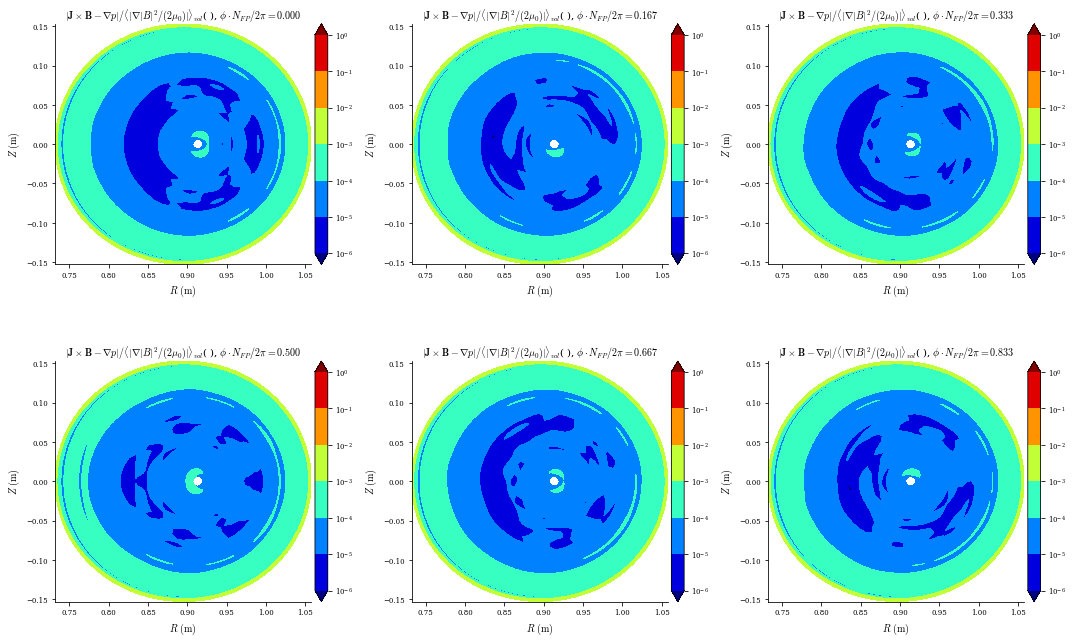

In [17]:
plot_section(eq, "|F|_normalized", log=True);

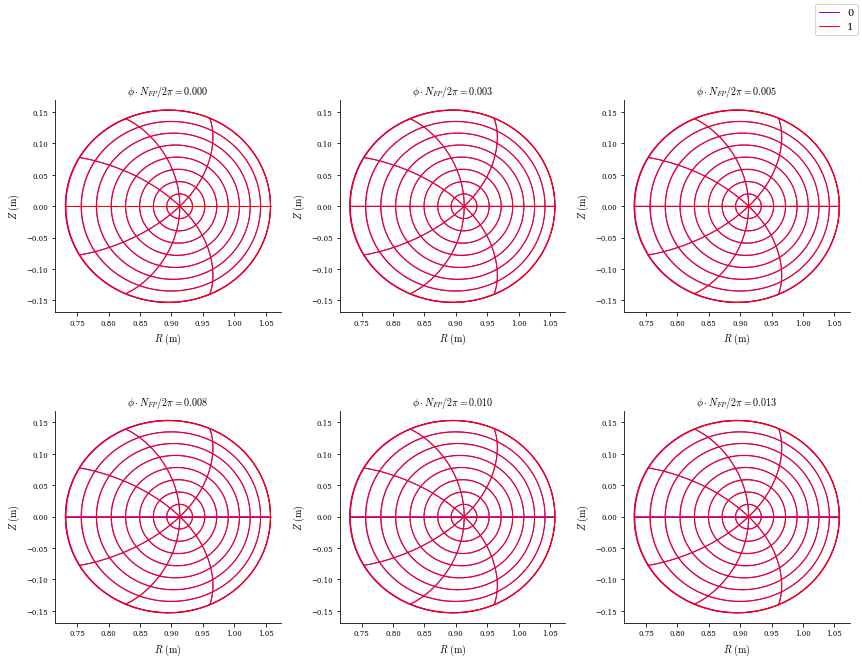

In [18]:
plot_comparison([eq0, eq0_lowres_fb], phi=6);

# Get Free Boundary with Low Umbilic Coil Current

In [19]:
minor_radius = eq.compute("a")["a"]
offset = 1.4 * minor_radius
zeta = np.linspace(0, 2 * np.pi, 41)
helical_offset = 0
R0 = eq.surface.R_lmn[eq.surface.R_basis.get_idx(0, 0, 0)]
# assumes that theta = zeta - helical_offset for n/m=1 umbilic coil
# use m * theta - n * zeta = - helical_offset for general n/m
# parametrization of a curve is R = R0 + offset * cos(theta)
# and Z = offset * sin(theta)
R = R0 + offset * np.cos(zeta - helical_offset)
Z = offset * np.sin(zeta - helical_offset)

data = jnp.vstack([R, zeta, Z]).T
umbilic_coil = FourierRZCoil.from_values(
    current=-2.1e3,
    coords=data,
    N=10,
    basis="rpz",
)
coil_grid = LinearGrid(N=50)

helical_offset = np.pi
R = R0 + offset * np.cos(zeta - helical_offset)
Z = offset * np.sin(zeta - helical_offset)

data = jnp.vstack([R, zeta, Z]).T
umbilic_coil2 = FourierRZCoil.from_values(
    current=-2.1e3,
    coords=data,
    N=10,
    basis="rpz",
)

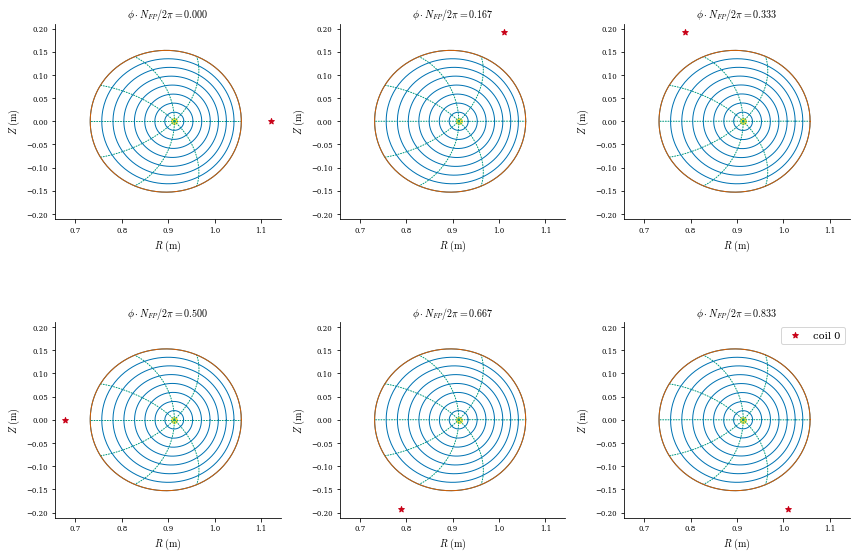

In [20]:
plot_coil_and_surfaces(eq, coils=[umbilic_coil, umbilic_coil2] if use_coil2 else umbilic_coil)

In [21]:
field = field0.copy()
Ic = 1000
umbilic_coil.current = Ic
umbilic_coil2.current = Ic
field.append(umbilic_coil)
if use_coil2:
    field.append(umbilic_coil2)

## Get Free Boundary for Low Umbilic Coil Current

In [22]:
eq = eq0_lowres_fb.copy()

In [23]:
objective = ObjectiveFunction(
    BoundaryError(
        eq=eq,
        field=field,
        field_fixed=True,
        field_grid=coil_grid,
        source_grid=source_grid,
        eval_grid=eval_grid,
        b_plasma_chunk_size=200,
        bs_chunk_size=200,
    ),
    jac_chunk_size=1,
)
constraints = (
    ForceBalance(eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid)),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

In [24]:
try:
    eq = load(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c1000-k4.h5")
except FileNotFoundError:
    k = 4
    R_modes = np.vstack(
        (
            [0, 0, 0],  # kind of cheating...
            eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :],
        )
    )
    Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
    bdry_constraints = (
        FixBoundaryR(eq=eq, modes=R_modes),
        FixBoundaryZ(eq=eq, modes=Z_modes),
    )
    eq, out = eq.optimize(
        objective,
        constraints + bdry_constraints,
        optimizer="proximal-lsq-exact",
        x_scale="ess",
        verbose=3,
        maxiter=20,
        ftol=1e-3,
        options={"solve_options": {"ftol": 1e-3, "gtol": 0, "xtol": 0, "verbose": 0}},
    )

In [25]:
eq_coil_1000 = eq.copy()
eq_coil_1000.save(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c1000-k4.h5")

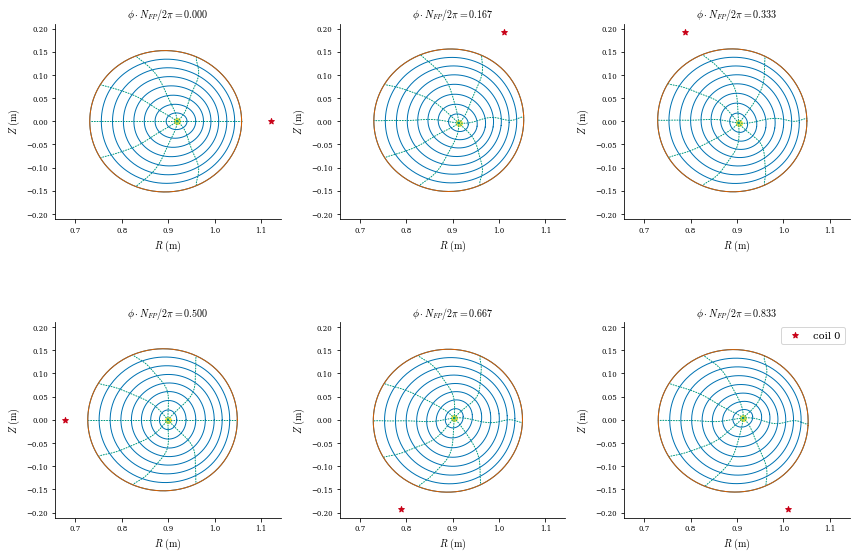

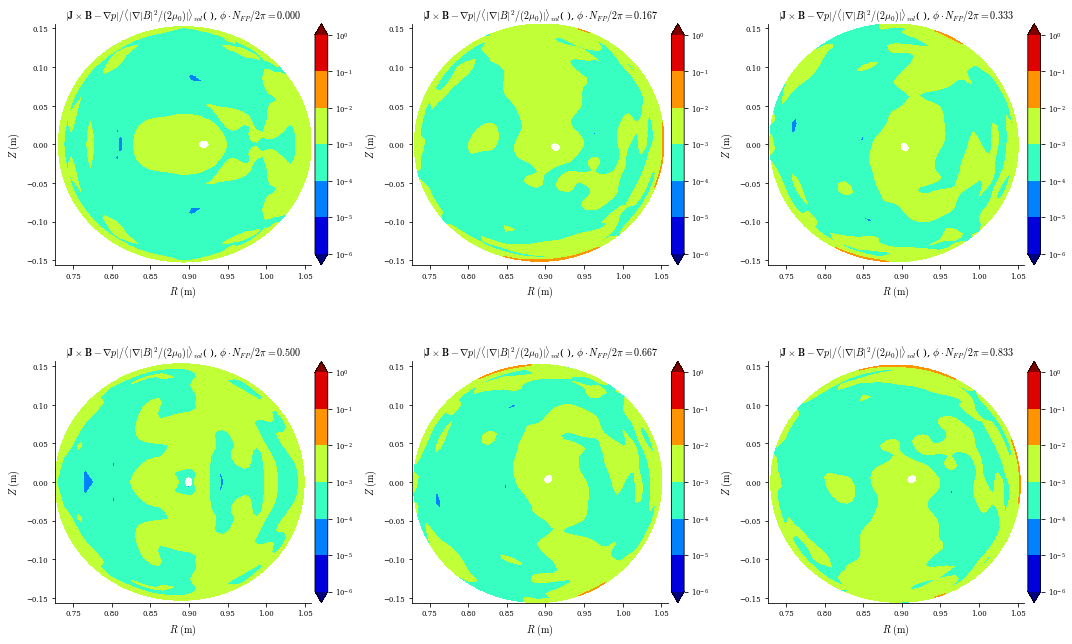

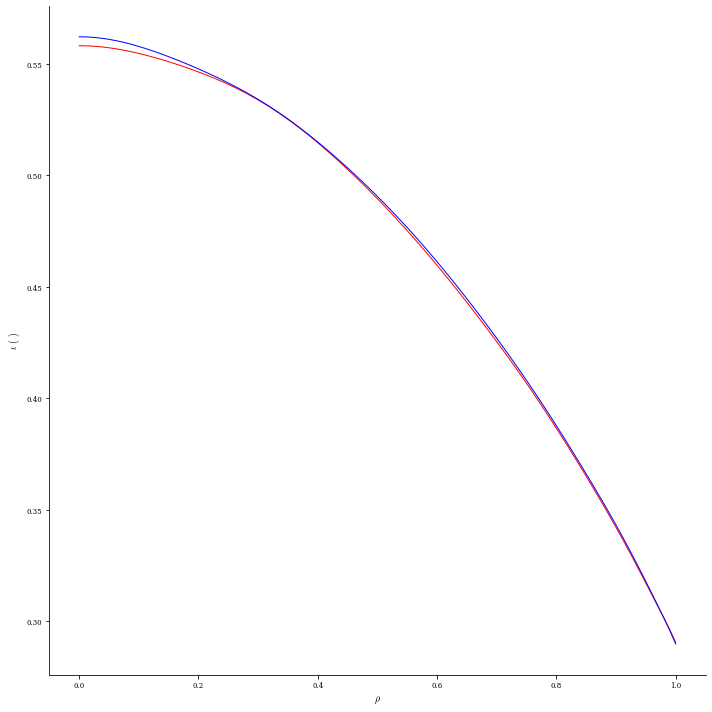

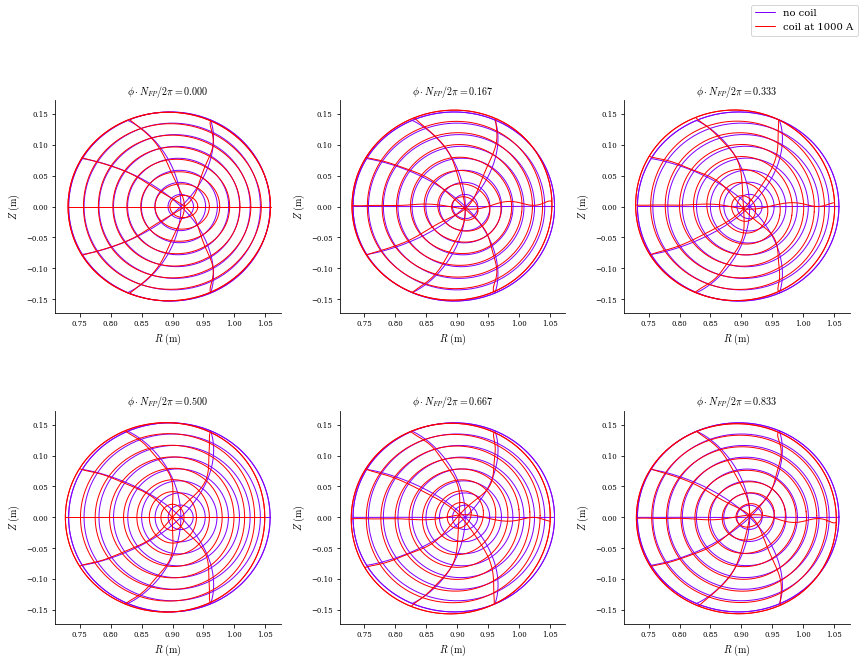

In [26]:
plot_coil_and_surfaces(
    eq_coil_1000, coils=[umbilic_coil, umbilic_coil2] if use_coil2 else umbilic_coil
)
plot_section(eq_coil_1000, "|F|_normalized", log=True);
fig, ax = plot_1d(eq_coil_1000, "iota", color="red", figsize=(10,10))
plot_1d(eq0_lowres_fb, "iota", ax=ax, color="blue");
plot_comparison([eq0_lowres_fb, eq_coil_1000], labels=["no coil", "coil at 1000 A"], phi=6);

# Slightly higher coil current

In [27]:
field = field0.copy()
Ic = 2000
umbilic_coil.current = Ic
umbilic_coil2.current = Ic
field.append(umbilic_coil)
if use_coil2:
    field.append(umbilic_coil2)

In [28]:
eq = eq_coil_1000.copy()

In [29]:
objective = ObjectiveFunction(
    BoundaryError(
        eq=eq,
        field=field,
        field_fixed=True,
        field_grid=coil_grid,
        source_grid=source_grid,
        eval_grid=eval_grid,
        b_plasma_chunk_size=200,
        bs_chunk_size=200,
    ),
    jac_chunk_size=1,
)
constraints = (
    ForceBalance(eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid)),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

In [30]:
try:
    eq = load(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c2000-k4.h5")
except FileNotFoundError:
    k = 4
    R_modes = np.vstack(
        (
            [0, 0, 0],  # kind of cheating...
            eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :],
        )
    )
    Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
    bdry_constraints = (
        FixBoundaryR(eq=eq, modes=R_modes),
        FixBoundaryZ(eq=eq, modes=Z_modes),
    )
    eq, out = eq.optimize(
        objective,
        constraints + bdry_constraints,
        optimizer="proximal-lsq-exact",
        x_scale="ess",
        verbose=3,
        maxiter=20,
        ftol=1e-3,
        options={"solve_options": {"ftol": 1e-3, "gtol": 0, "xtol": 0, "verbose": 0}},
    )

In [31]:
eq_coil_2000 = eq.copy()
eq_coil_2000.save(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c2000-k4.h5")

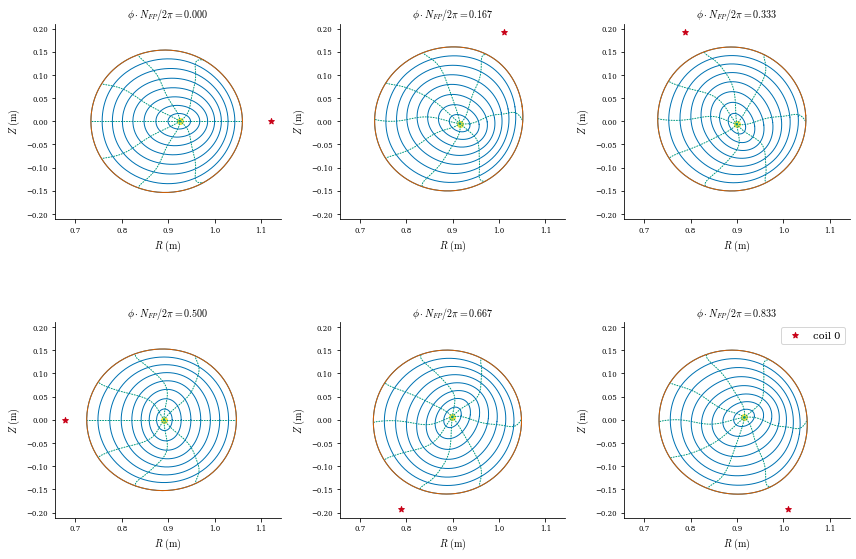

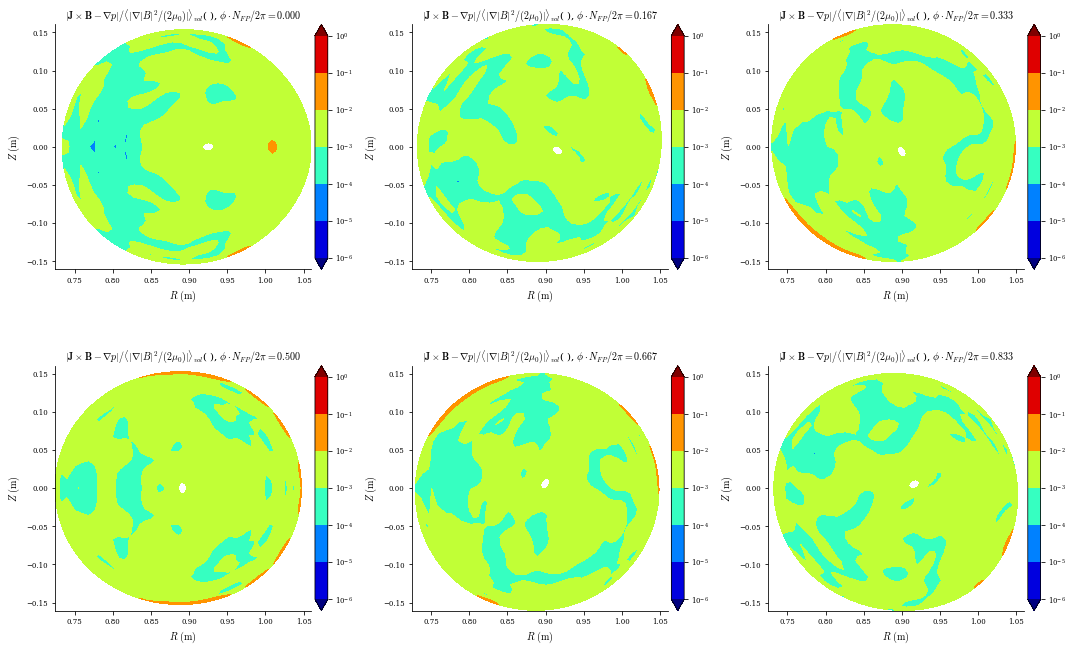

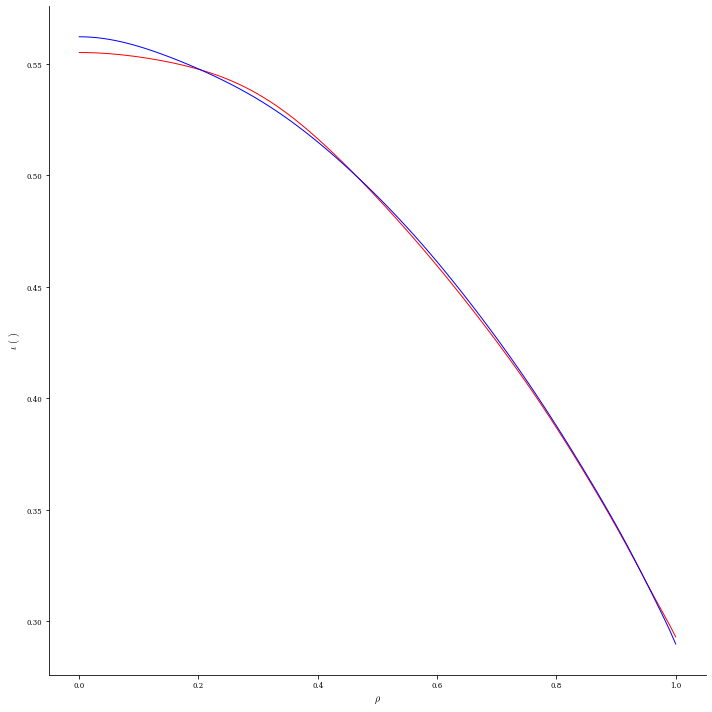

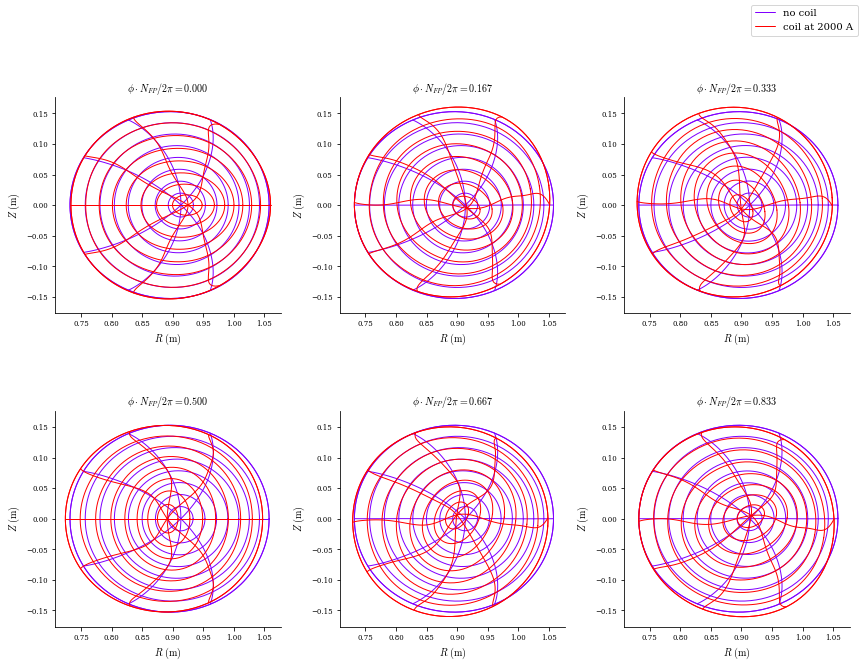

In [32]:
plot_coil_and_surfaces(
    eq_coil_2000, coils=[umbilic_coil, umbilic_coil2] if use_coil2 else umbilic_coil
)
plot_section(eq_coil_2000, "|F|_normalized", log=True);
fig, ax = plot_1d(eq_coil_2000, "iota", color="red", figsize=(10,10))
plot_1d(eq0_lowres_fb, "iota", ax=ax, color="blue");
plot_comparison([eq0_lowres_fb, eq_coil_2000], labels=["no coil", "coil at 2000 A"], phi=6);

# 3000A Current

In [33]:
field = field0.copy()
Ic = 3000
umbilic_coil.current = Ic
umbilic_coil2.current = Ic
field.append(umbilic_coil)
if use_coil2:
    field.append(umbilic_coil2)

In [34]:
eq = eq_coil_2000.copy()

In [35]:
objective = ObjectiveFunction(
    BoundaryError(
        eq=eq,
        field=field,
        field_fixed=True,
        field_grid=coil_grid,
        source_grid=source_grid,
        eval_grid=eval_grid,
        b_plasma_chunk_size=200,
        bs_chunk_size=200,
    ),
    jac_chunk_size=1,
)
constraints = (
    ForceBalance(eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid)),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

In [36]:
try:
    eq = load(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c3000-k4.h5")
except FileNotFoundError:
    k = 4
    R_modes = np.vstack(
        (
            [0, 0, 0],  # kind of cheating...
            eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :],
        )
    )
    Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
    bdry_constraints = (
        FixBoundaryR(eq=eq, modes=R_modes),
        FixBoundaryZ(eq=eq, modes=Z_modes),
    )
    eq, out = eq.optimize(
        objective,
        constraints + bdry_constraints,
        optimizer="proximal-lsq-exact",
        x_scale="ess",
        verbose=3,
        maxiter=20,
        ftol=1e-3,
        options={"solve_options": {"ftol": 1e-3, "gtol": 0, "xtol": 0, "verbose": 0}},
    )

In [37]:
eq_coil_3000 = eq.copy()
eq_coil_3000.save(f"./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb-L{eq.L}M{eq.M}N{eq.N}-{2 if use_coil2 else 1}c3000-k4.h5")

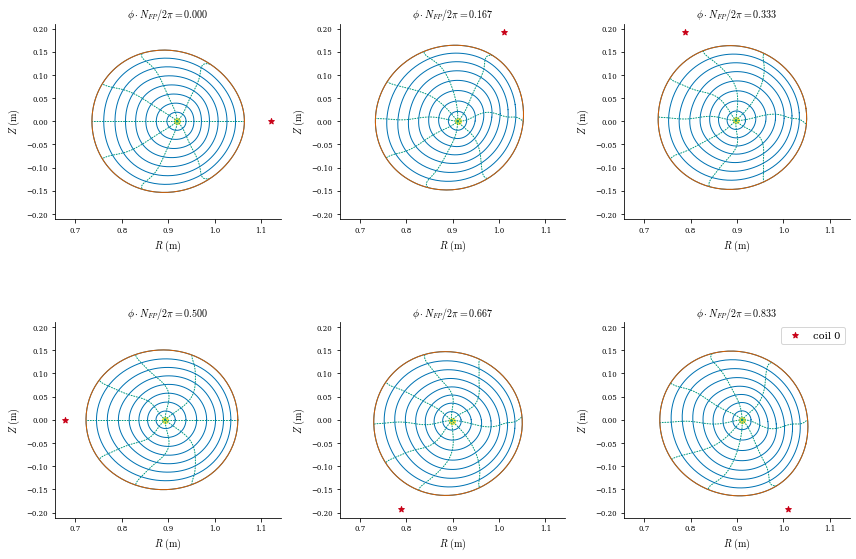

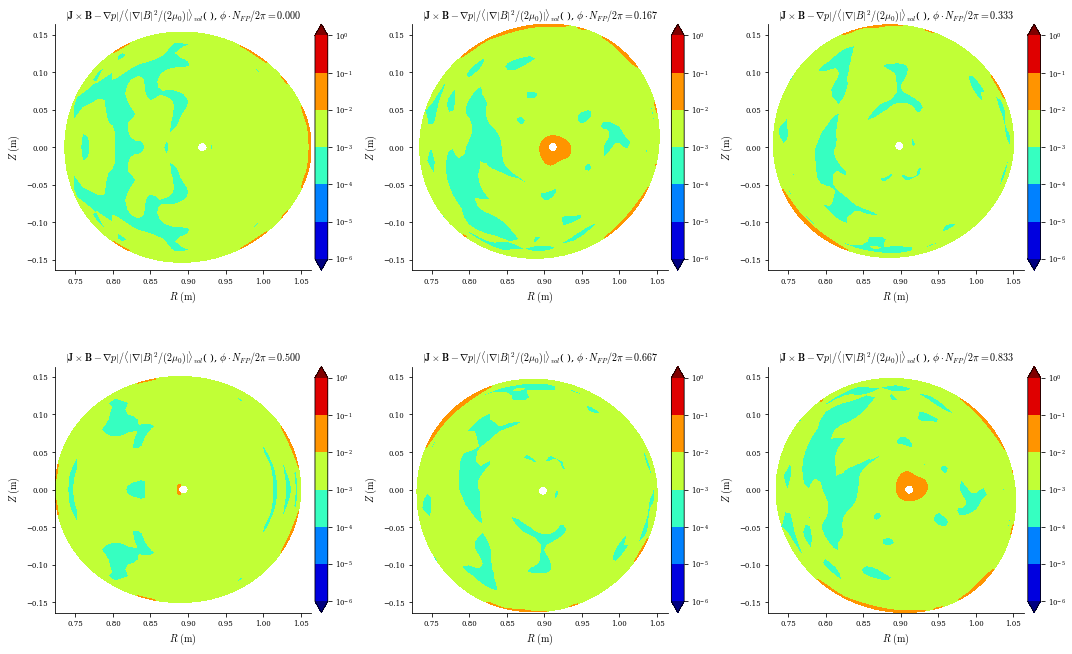

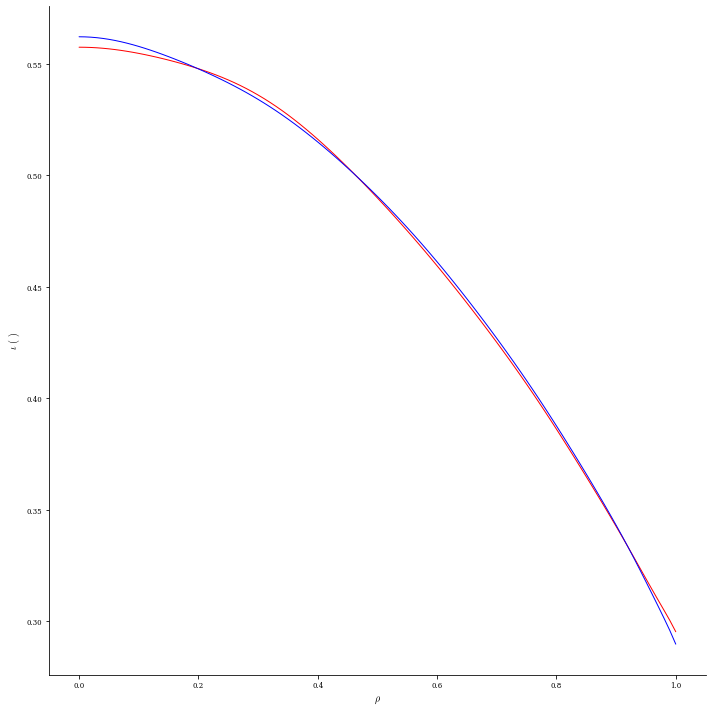

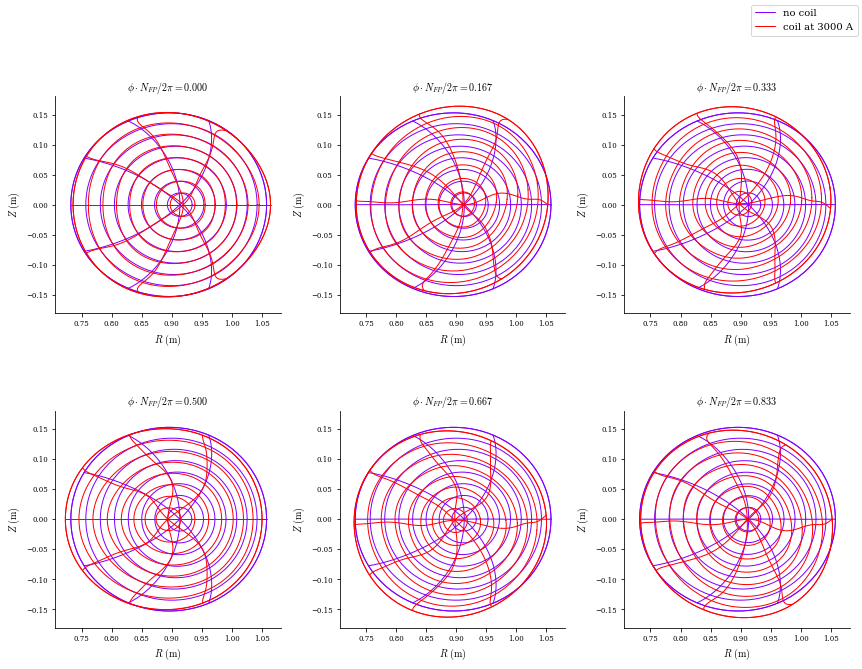

In [38]:
plot_coil_and_surfaces(
    eq_coil_3000, coils=[umbilic_coil, umbilic_coil2] if use_coil2 else umbilic_coil
)
plot_section(eq_coil_3000, "|F|_normalized", log=True);
fig, ax = plot_1d(eq_coil_3000, "iota", color="red", figsize=(10,10))
plot_1d(eq0_lowres_fb, "iota", ax=ax, color="blue");
plot_comparison([eq0_lowres_fb, eq_coil_3000], labels=["no coil", "coil at 3000 A"], phi=6);